# 02. Предобработка и формирование признаков

В этом ноутбуке:
- загружаем все 11 поездок из `log/*.h5`;
- удаляем явно некорректные значения угла руля (|angle| > 540°), что соответствует более чем 1,5 оборота в руля в одну сторону, что вне допустимых значений для автомобиля;
- формируем целевую переменную `maneuver_class` (straight / turn_left / turn_right);
- сохраняем очищенный датасет в `data/processed/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_ROOT = Path("../data/raw/dataset/log")

h5_files = sorted(DATA_ROOT.glob("*.h5"))
print("Найдено файлов:", len(h5_files))
for p in h5_files:
    print(" ", p.name)

Найдено файлов: 11
  2016-01-30--11-24-51.h5
  2016-01-30--13-46-00.h5
  2016-01-31--19-19-25.h5
  2016-02-02--10-16-58.h5
  2016-02-08--14-56-28.h5
  2016-02-11--21-32-47.h5
  2016-03-29--10-50-20.h5
  2016-04-21--14-48-08.h5
  2016-05-12--22-20-00.h5
  2016-06-02--21-39-29.h5
  2016-06-08--11-46-01.h5


In [2]:
import h5py
import numpy as np
import pandas as pd

OUTLIER_THRESHOLD = 540
STEER_THRESHOLD = 10

def make_label(angle: float, threshold: float = STEER_THRESHOLD) -> str:
    if angle > threshold:
        return "turn_right"
    elif angle < -threshold:
        return "turn_left"
    else:
        return "straight"


def load_trip(filepath: Path) -> pd.DataFrame:
    with h5py.File(filepath, "r") as f:
        df = pd.DataFrame()
        df["t"]              = f["times"][:]
        df["speed"]          = f["speed"][:]
        df["steering_angle"] = f["steering_angle"][:]
        df["car_accel"]      = f["car_accel"][:]
        df["gas"]            = f["gas"][:]
        df["brake"]          = f["brake"][:]
        df["rpm"]            = f["rpm"][:]

        if "imu_accel" in f:
            imu_a = f["imu_accel"][:]
            df["imu_ax"] = imu_a[:, 0]
            df["imu_ay"] = imu_a[:, 1]
            df["imu_az"] = imu_a[:, 2]
        else:
            df["imu_ax"] = np.nan
            df["imu_ay"] = np.nan
            df["imu_az"] = np.nan

        if "imu_gyro" in f:
            imu_g = f["imu_gyro"][:]
            df["imu_gx"] = imu_g[:, 0]
            df["imu_gy"] = imu_g[:, 1]
            df["imu_gz"] = imu_g[:, 2]
        else:
            df["imu_gx"] = np.nan
            df["imu_gy"] = np.nan
            df["imu_gz"] = np.nan

        df["trip"] = filepath.stem

    mask = df["steering_angle"].abs() <= OUTLIER_THRESHOLD
    df = df[mask].copy()

    df["maneuver_class"] = df["steering_angle"].apply(make_label)

    return df

In [3]:
all_trips = []

for path in h5_files:
    print(f"\nЗагружаю {path.name} ...", end=" ")
    trip_df = load_trip(path)
    print(trip_df.shape)
    all_trips.append(trip_df)

df_all = pd.concat(all_trips, ignore_index=True)
print("\nИтоговый размер df_all:", df_all.shape)


Загружаю 2016-01-30--11-24-51.h5 ... (252666, 15)

Загружаю 2016-01-30--13-46-00.h5 ... (286831, 15)

Загружаю 2016-01-31--19-19-25.h5 ... (93572, 15)

Загружаю 2016-02-02--10-16-58.h5 ... (272830, 15)

Загружаю 2016-02-08--14-56-28.h5 ... (126474, 15)

Загружаю 2016-02-11--21-32-47.h5 ... (417005, 15)

Загружаю 2016-03-29--10-50-20.h5 ... (381381, 15)

Загружаю 2016-04-21--14-48-08.h5 ... (143350, 15)

Загружаю 2016-05-12--22-20-00.h5 ... (250109, 15)

Загружаю 2016-06-02--21-39-29.h5 ... (211027, 15)

Загружаю 2016-06-08--11-46-01.h5 ... (85133, 15)

Итоговый размер df_all: (2520378, 15)


##  Проверка качества данных и баланса классов

На этом шаге:
- проверяем пропуски и базовую статистику по основным признакам;
 - оцениваем баланс классов `maneuver_class` на всём датасете.

df_all shape: (2520378, 15)
t                 float64
speed             float64
steering_angle    float64
car_accel         float64
gas               float64
brake             float64
rpm               float64
imu_ax            float64
imu_ay            float64
imu_az            float64
imu_gx            float64
imu_gy            float64
imu_gz            float64
trip                  str
maneuver_class        str
dtype: object


,t,speed,steering_angle,car_accel,gas,brake,rpm,imu_ax,imu_ay,imu_az,imu_gx,imu_gy,imu_gz,trip,maneuver_class
0,0.00,0.0,80.0,0.0,0.0,63872.0,0.0,-0.310000,9.640000,-0.330000,0.000000,-0.062500,0.000000,2016-01-30--11-24-51,turn_right
1,0.01,0.0,80.0,0.0,0.0,63872.0,0.0,-0.314084,9.631832,-0.321832,0.000000,-0.062500,-0.025527,2016-01-30--11-24-51,turn_right
2,0.02,0.0,80.0,0.0,0.0,63872.0,0.0,-0.310612,9.624694,-0.314694,0.058672,-0.033164,-0.091836,2016-01-30--11-24-51,turn_right
3,0.03,0.0,80.0,0.0,0.0,63872.0,0.0,-0.304536,9.632268,-0.322268,0.082473,-0.014176,-0.110824,2016-01-30--11-24-51,turn_right
4,0.04,0.0,80.0,0.0,0.0,63872.0,0.0,-0.317773,9.637773,-0.347814,-0.034666,-0.048583,-0.048583,2016-01-30--11-24-51,turn_right



Пропуски по колонкам:


imu_ax            1071000
imu_ay            1071000
imu_az            1071000
imu_gx            1071000
imu_gy            1071000
imu_gz            1071000
t                       0
speed                   0
steering_angle          0
car_accel               0
gas                     0
brake                   0
rpm                     0
trip                    0
maneuver_class          0
dtype: int64

,speed,steering_angle,car_accel,gas,brake
count,2520378.00,2520378.00,2520378.00,2520378.00,2520378.00
mean,18.91,0.57,-0.01,0.12,799.37
std,10.99,66.25,0.61,0.13,5957.63
min,-1.59,-540.00,-7.70,0.00,-76.73
25%,8.49,-18.00,-0.22,0.00,0.00
50%,23.77,-4.00,0.00,0.10,0.00
75%,27.94,13.00,0.20,0.22,14.65
max,35.88,540.00,5.12,1.00,63872.00



Распределение классов:
maneuver_class
straight      919073
turn_left     917546
turn_right    683759
Name: count, dtype: int64

Доли классов:


maneuver_class
straight      0.365
turn_left     0.364
turn_right    0.271
Name: count, dtype: float64

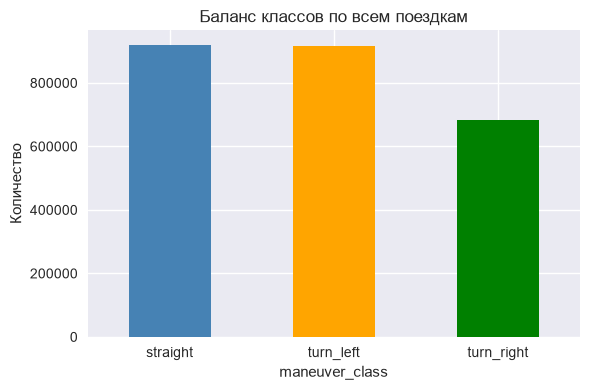

In [4]:
# размеры и типы колонок
print("df_all shape:", df_all.shape)
print(df_all.dtypes)

# первые строки
display(df_all.head())

# пропуски по колонкам
print("\nПропуски по колонкам:")
display(df_all.isnull().sum().sort_values(ascending=False))

# базовая статистика по основным числовым признакам
num_cols = ["speed", "steering_angle", "car_accel", "gas", "brake"]
display(df_all[num_cols].describe().round(2))

# баланс классов
counts = df_all["maneuver_class"].value_counts()
print("\nРаспределение классов:")
print(counts)

print("\nДоли классов:")
display((counts / len(df_all)).round(3))

counts.plot(kind="bar", color=["steelblue", "orange", "green"],
            figsize=(6, 4), title="Баланс классов по всем поездкам")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Обработка признаков IMU и добавление простых оконных признаков

- так как не во всех поездках есть imu-данные, удаляем эти колонки, либо заполняем пропуски;
- дополнительно создаем простые оконные признаки (скользящее среднее и std для скорости и угла руля).

In [5]:
imu_cols = ["imu_ax", "imu_ay", "imu_az", "imu_gx", "imu_gy", "imu_gz"]
existing_imu_cols = [c for c in imu_cols if c in df_all.columns]

print("Удаляю imu-колонки:", existing_imu_cols)
df_all = df_all.drop(columns=existing_imu_cols)

Удаляю imu-колонки: ['imu_ax', 'imu_ay', 'imu_az', 'imu_gx', 'imu_gy', 'imu_gz']


## Сохранение предобработанного датасета

Сохраняем итоговый датасет с целевой переменной `maneuver_class`
и сформированными признаками в `data/processed/`.
Этот файл будет использоваться в ноутбуке с моделированием.

In [6]:
from pathlib import Path

PROCESSED_PATH = Path("../data/processed/telemetry_preprocessed.parquet")
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

df_all.to_parquet(PROCESSED_PATH, index=False)
print("Сохранено в:", PROCESSED_PATH.resolve())

Сохранено в: /Users/ivank/PycharmProjects/commaai/data/processed/telemetry_preprocessed.parquet


Проверяем, все ли ОК с файлом

In [7]:
from pathlib import Path
import pandas as pd

PROCESSED_PATH = Path("../data/processed/telemetry_preprocessed.parquet")

df_check = pd.read_parquet(PROCESSED_PATH)
print("df_check shape:", df_check.shape)
df_check.head()

df_check shape: (2520378, 9)


,t,speed,steering_angle,car_accel,gas,brake,rpm,trip,maneuver_class
0,0.00,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
1,0.01,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
2,0.02,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
3,0.03,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
4,0.04,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right


In [8]:
df_check.info()
df_check.isnull().sum().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 2520378 entries, 0 to 2520377
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   t               float64
 1   speed           float64
 2   steering_angle  float64
 3   car_accel       float64
 4   gas             float64
 5   brake           float64
 6   rpm             float64
 7   trip            str    
 8   maneuver_class  str    
dtypes: float64(7), str(2)
memory usage: 242.5 MB


t                 0
speed             0
steering_angle    0
car_accel         0
gas               0
brake             0
rpm               0
trip              0
maneuver_class    0
dtype: int64

In [9]:
counts = df_check["maneuver_class"].value_counts()
print("Распределение классов:")
print(counts)

print("\nДоли классов:")
print((counts / len(df_check)).round(3))

Распределение классов:
maneuver_class
straight      919073
turn_left     917546
turn_right    683759
Name: count, dtype: int64

Доли классов:
maneuver_class
straight      0.365
turn_left     0.364
turn_right    0.271
Name: count, dtype: float64


In [10]:
print("Равны ли датафреймы:", df_check.equals(df_all))

Равны ли датафреймы: True


Вот и прекрасно, что с ним все OK

## Итоги предобработки

На этом шаге:

- загружены и объединены данные по всем 11 поездкам из `log/*.h5`;
- удалены явно некорректные значения угла руля (|steering_angle| > 540°), соответствующие невозможным для автомобиля оборотам;
- сформирована целевая переменная `maneuver_class` с классами `straight`, `turn_left`, `turn_right` на основе порога 10°;
- собран итоговый датафрейм `df_all` размером порядка 2,5 млн наблюдений и 15 признаков, включающих скорость, угол руля, педали, обороты двигателя и показания IMU;
- сохранён очищенный датасет в `data/processed/telemetry_preprocessed.parquet` для дальнейшего моделирования в ноутбуке `03_modeling.ipynb`.